In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error 

In [107]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("denkuznetz/taxi-price-prediction")

print("Path to dataset files:", path)

df_path = os.path.join(path, 'taxi_trip_pricing.csv')
df = pd.read_csv(df_path)


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\denkuznetz\taxi-price-prediction\versions\1


In [108]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [109]:
df.isna().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [110]:
df['Time_of_Day'] = df['Time_of_Day'].map({'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3})
df['Day_of_Week'] = df['Day_of_Week'].map({'Weekday': 0, 'Weekend': 1})
df['Traffic_Conditions'] = df['Traffic_Conditions'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Weather'] = df['Weather'].map({'Snow': 0, 'Rain': 1, 'Clear': 2})

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    float64
 2   Day_of_Week            950 non-null    float64
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    float64
 5   Weather                950 non-null    float64
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(11)
memory usage: 86.1 KB


In [112]:
df = df.dropna(subset=['Trip_Price']) # Удаляем строки с пропущенной целевой переменной

In [113]:
df=df.copy()

In [114]:
for column in df.select_dtypes(include=['number']).columns:
    df[column] = df[column].fillna(df[column].mean())

In [115]:
X = df.drop(columns=["Trip_Price"])
y = df["Trip_Price"]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [117]:
linear.coef_   #коэффициенты модели (веса признаков). Показывает, как каждый признак влияет на цену поездки

array([ 1.70679494e+00, -7.05193702e-01, -5.26774747e-02, -2.13842500e-01,
        9.32790494e-01, -2.42417067e-01,  2.52691789e-03,  2.49981328e+01,
        5.46574569e+01,  3.01095415e-01])

In [118]:
linear.intercept_    #свободный член (bias). Значение цены, когда все признаки равны нулю

np.float64(-54.06826018656024)

In [119]:
# Linnear Regression
linear = LinearRegression().fit(X_train, y_train)
y_predict = linear.predict(X_test)

In [120]:
from sklearn.model_selection import cross_val_score

cv_scores_linear = cross_val_score(linear, X_train, y_train, cv=5, scoring='r2')

In [121]:
CV_r2_mean_linreg =  cv_scores_linear.mean()
CV_r2_mean_linreg

np.float64(0.8475726788295292)

In [122]:
linear_score = linear.score(X_train, y_train)
linear_score

0.8563283112403208

In [123]:
mae_linear = mean_absolute_error(y_test, y_predict)
mae_linear

9.817684218138336

In [124]:
mse_linear = mean_squared_error(y_test, y_predict)
mse_linear

285.9487796735413

In [125]:
from sklearn.metrics import r2_score

r2_linear = r2_score(y_test, y_predict) 
r2_linear

0.8776626309159546

In [126]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


In [127]:
cv_scores_dt = cross_val_score(dt, X_train, y_train, cv=5, scoring='r2')

In [128]:
mae_dt =  mean_absolute_error(y_test, y_pred_dt)
print(mae_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(r2_dt)
CV_r2_mean_dt = cv_scores_dt.mean()
print(CV_r2_mean_dt)

10.094596773650775
293.4863945922499
0.8744378156907375
0.8575492962946001


In [129]:
#Random Forest
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Cross-validation scores: {cv_scores_rf}")
print(f"Average CV score: {cv_scores_rf.mean():.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"R² score: {r2_score(y_test, y_pred_rf):.4f}%")

Cross-validation scores: [0.95337596 0.94935235 0.87466363 0.9178424  0.91462823]
Average CV score: 0.922
MSE: 133.81
MAE: 6.31
R² score: 0.9428%


In [130]:
# CatBoost
from catboost import CatBoostRegressor

catboost = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=False
)
catboost.fit(X_train, y_train)

y_pred_cb = catboost.predict(X_test)

cv_scores_cb = cross_val_score(catboost, X_train, y_train, cv=5, scoring='r2')

mse_cb = mean_squared_error(y_test, y_pred_cb)
mae_cb = mean_absolute_error(y_test, y_pred_cb)
r2_cb = r2_score(y_test, y_pred_cb) 
CV_r2_mean_cb = cv_scores_cb.mean()

print(f"MSE: {mse_cb:.2f}")
print(f"MAE: {mae_cb:.2f}")
print(f"R² score: {r2_cb:.4f}")
print(f"CV_r2_mean: {CV_r2_mean_cb:.4f}")

MSE: 274.10
MAE: 5.67
R² score: 0.8827
CV_r2_mean: 0.9007


In [131]:
# Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

nn_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) 
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',  
    metrics=['mae'] 
)

history = nn_model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)
y_pred_scaled = nn_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_nn = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()


# Метрики
mse_nn = mean_squared_error(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn) 

print(f"MSE: {mse_nn:.2f}")
print(f"MAE: {mae_nn:.2f}")
print(f"R² score: {r2_nn:.4f}")

C:\Users\Admin\anadonda2\envs\ml-labs\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MSE: 175.74
MAE: 5.59
R² score: 0.9248


In [132]:
from sklearn import linear_model
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, random_state=42)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [133]:
cv_scores_lasso = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')

In [134]:
lasso.coef_

array([ 1.70451428, -0.5228458 , -0.        , -0.10906976,  0.71207332,
       -0.        , -0.        , 24.48487336, 46.54543228,  0.30154033])

In [135]:
lasso.intercept_

np.float64(-51.711311283935046)

In [136]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
CV_r2_mean_lasso = cv_scores_lasso.mean()
print(f'MSE методом лассо : {mse_lasso}')
print(f'MAE методом лассо : {mae_lasso}')
print(f'r2 лассо : {r2_lasso}')
print(f'CV_r2_mean лассо : {CV_r2_mean_lasso}')

MSE методом лассо : 291.4091689284325
MAE методом лассо : 9.923522812030521
r2 лассо : 0.8753265144394974
CV_r2_mean лассо : 0.8479139164601746


In [137]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [138]:
cv_scores_ridge = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')

In [139]:
ridge.coef_

array([ 1.70520891e+00, -6.71907800e-01, -2.95189540e-02, -1.98853642e-01,
        9.26116149e-01, -2.59490344e-01, -1.28482172e-02,  2.48528248e+01,
        4.93964629e+01,  3.01150373e-01])

In [140]:
ridge.intercept_

np.float64(-52.296023637242584)

In [141]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
CV_r2_mean_ridge = cv_scores_ridge.mean()

print(f'Оценка MSE методом ridge : {mse_ridge}')
print(f'Оценка MAE методом ridge : {mae_ridge}')
print(f'r2 : {r2_ridge}')
print(f'CV_r2_mean : {CV_r2_mean_ridge}')

Оценка MSE методом ridge : 289.07719671655826
Оценка MAE методом ridge : 9.887201903583643
r2 : 0.8763242013172086
CV_r2_mean : 0.84751755157162



 best model: Neural Network
   MAE: 5.5934
   R²:  0.9248 (92.48%)


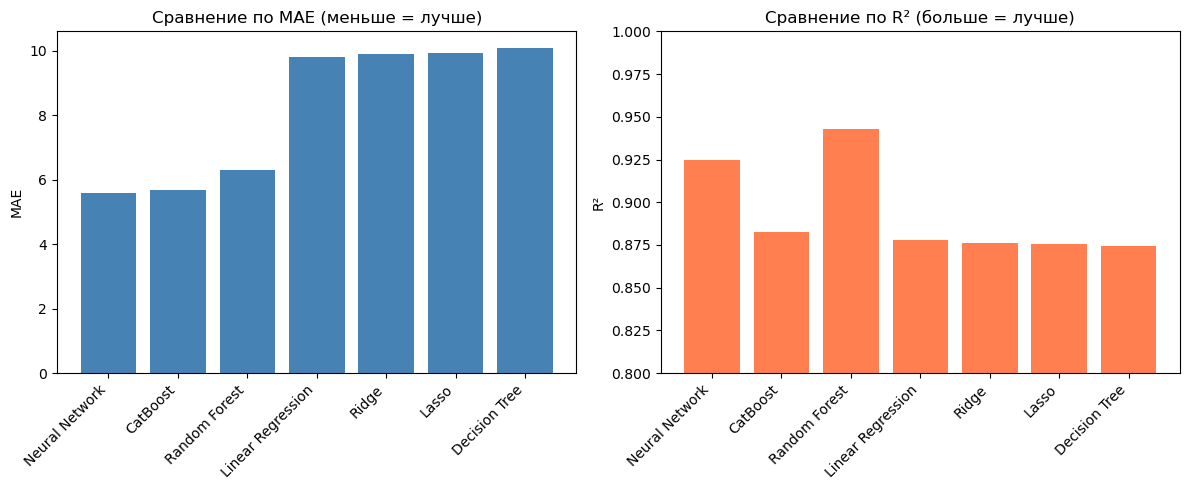

In [142]:
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'CatBoost', 
              'Neural Network', 'Lasso', 'Ridge'],
    'MAE': [mae_linear, mae_dt, mae_rf, mae_cb, mae_nn, mae_lasso, mae_ridge],
    'MSE': [mse_linear, mse_dt, mse_rf, mse_cb, mse_nn, mse_lasso, mse_ridge],
    'R2': [r2_linear, r2_dt, r2_rf, r2_cb, r2_nn, r2_lasso, r2_ridge],
    'CV_R2': [CV_r2_mean_linreg, CV_r2_mean_dt, cv_scores_rf.mean(), 
              CV_r2_mean_cb, 'N/A', CV_r2_mean_lasso, CV_r2_mean_ridge]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAE')



best = results_df.iloc[0]
print(f"\n best model: {best['Model']}")
print(f"   MAE: {best['MAE']:.4f}")
print(f"   R²:  {best['R2']:.4f} ({best['R2']*100:.2f}%)")

# График
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(results_df['Model'], results_df['MAE'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE')
plt.title('Сравнение по MAE (меньше = лучше)')

plt.subplot(1, 2, 2)
plt.bar(results_df['Model'], results_df['R2'], color='coral')
plt.xticks(rotation=45, ha='right')
plt.ylabel('R²')
plt.title('Сравнение по R² (больше = лучше)')
plt.ylim(0.8, 1.0)

plt.tight_layout()
plt.show()